# 00. Régression Linéaire Simple - Version Simplifiée

**Objectif** : Une version simple et claire de la régression linéaire pour débutants

**Pour les débutants** : Ce notebook explique chaque étape simplement

In [1]:
# Importer les bibliothèques essentielles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modèles et outils de machine learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

print("📚 Bibliothèques importées avec succès !")

📚 Bibliothèques importées avec succès !


In [2]:
# Charger les données
df = pd.read_csv("../data/real_estate_processed.csv")

print(f"📊 Nous avons {df.shape[0]} annonces immobilières")
print(f"🔢 Avec {df.shape[1]} caractéristiques")
print("\n📋 Aperçu des données :")
df.head()

📊 Nous avons 5653 annonces immobilières
🔢 Avec 12 caractéristiques

📋 Aperçu des données :


,title,price_text,price,category,city,location,type_transaction,rooms,post_time,post_date,post_month,post_year
0,À louer – Bureaux neufs S+1 et S+2 à Monastir ...,650 DT,650,0,Monastir,Monastir,0,1,2/4/26 12:37,02-04-26,2,2026
1,S+1 haut standing pour la saison universitaire,850 DT,850,0,Monastir,Monastir,0,1,8/30/25 10:49,08-30-25,8,2025
2,à vendre s+3 haut standing directement au prom...,350000 DT,350000,1,Monastir,Bekalta,1,3,7/30/25 12:45,07-30-25,7,2025
3,Appartement s+1 vue sur mer pour vacance d’été...,1540 DT,1540,2,Monastir,Bekalta,0,1,6/17/25 9:41,06-17-25,6,2025
4,Studio mignon estivale,55 DT,55,0,Monastir,Monastir,0,0,6/10/25 20:59,06-10-25,6,2025


In [3]:
# Nettoyer les données - garder les prix raisonnables
print("🧹 Nettoyage des données...")

# Garder uniquement les prix entre 50 DT et 10M DT
df_clean = df[(df['price'] >= 50) & (df['price'] <= 10000000)].copy()

print(f"   Données originales : {len(df)} annonces")
print(f"   Données nettoyées : {len(df_clean)} annonces")
print(f"   Supprimées : {len(df) - len(df_clean)} annonces")

# Utiliser les données nettoyées
df = df_clean

print(f"\n💰 Prix moyen : {df['price'].mean():.0f} DT")
print(f"💰 Prix médian : {df['price'].median():.0f} DT")

🧹 Nettoyage des données...
   Données originales : 5653 annonces
   Données nettoyées : 5601 annonces
   Supprimées : 52 annonces

💰 Prix moyen : 176410 DT
💰 Prix médian : 3500 DT


In [4]:
# Préparer les features (caractéristiques)
print("🔧 Préparation des features...")

# Garder uniquement les colonnes numériques pertinentes
features = ['category', 'type_transaction', 'post_month', 'post_year']
X = df[features]
y = df['price']

print(f"   Features utilisées : {features}")
print(f"   Shape de X : {X.shape}")
print(f"   Shape de y : {y.shape}")

🔧 Préparation des features...
   Features utilisées : ['category', 'type_transaction', 'post_month', 'post_year']
   Shape de X : (5601, 4)
   Shape de y : (5601,)


In [5]:
# Transformer la target (prix) avec log pour mieux gérer les extrêmes
print("📈 Transformation de la target...")

# Transformation logarithmique pour normaliser la distribution
y_log = np.log1p(y)  # log(1 + prix)

print(f"   Prix moyen original : {y.mean():.0f} DT")
print(f"   Prix moyen (log) : {y_log.mean():.4f}")
print(f"   ✅ Transformation appliquée")

📈 Transformation de la target...
   Prix moyen original : 176410 DT
   Prix moyen (log) : 9.6395
   ✅ Transformation appliquée


In [6]:
# Diviser les données en entraînement et test
print("📊 Division des données...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"   Entraînement : {X_train.shape[0]} annonces")
print(f"   Test : {X_test.shape[0]} annonces")

📊 Division des données...
   Entraînement : 4480 annonces
   Test : 1121 annonces


In [7]:
# Normaliser les features
print("⚙️ Normalisation des features...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"   ✅ Features normalisées")
print(f"   Shape X_train_scaled : {X_train_scaled.shape}")
print(f"   Shape X_test_scaled : {X_test_scaled.shape}")

⚙️ Normalisation des features...
   ✅ Features normalisées
   Shape X_train_scaled : (4480, 4)
   Shape X_test_scaled : (1121, 4)


In [8]:
# Créer et entraîner le modèle de régression linéaire
print("🤖 Création du modèle...")

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("   ✅ Modèle entraîné avec succès !")
print(f"   Coefficients : {model.coef_}")
print(f"   Intercept : {model.intercept_:.4f}")

🤖 Création du modèle...
   ✅ Modèle entraîné avec succès !
   Coefficients : [ 0.18819424  2.52902319 -0.06210794 -0.04252826]
   Intercept : 9.6727


In [9]:
# Faire des prédictions
print("🔮 Prédictions...")

# Prédictions sur les données d'entraînement et de test
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Revenir à l'échelle originale des prix
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred)
y_test_pred_orig = np.expm1(y_test_pred)

print("   ✅ Prédictions effectuées")
print(f"   Exemple - Prix réel : {y_test_orig.iloc[0]:.0f} DT")
print(f"   Exemple - Prix prédit : {y_test_pred_orig[0]:.0f} DT")

🔮 Prédictions...
   ✅ Prédictions effectuées
   Exemple - Prix réel : 250000 DT
   Exemple - Prix prédit : 275842 DT


In [18]:
# Calculer les métriques de performance
print("## Évaluation du modèle sur Train vs Test")

# Métriques sur les données d'entraînement
r2_train = r2_score(y_train_orig, y_train_pred_orig)
rmse_train = np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig))
mae_train = mean_absolute_error(y_train_orig, y_train_pred_orig)

# Métriques sur les données de test
r2_test = r2_score(y_test_orig, y_test_pred_orig)
rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
mae_test = mean_absolute_error(y_test_orig, y_test_pred_orig)

print(f"\n## Performance sur les données d'entraînement :")
print(f"   R² Score : {r2_train:.4f} ({r2_train*100:.1f}% de variance expliquée)")
print(f"   RMSE : {rmse_train:,.0f} DT")
print(f"   MAE : {mae_train:,.0f} DT")

print(f"\n## Performance sur les données de test :")
print(f"   R² Score : {r2_test:.4f} ({r2_test*100:.1f}% de variance expliquée)")
print(f"   RMSE : {rmse_test:,.0f} DT")
print(f"   MAE : {mae_test:,.0f} DT")

# Analyse de l'overfitting
overfitting_r2 = r2_train - r2_test
overfitting_rmse = rmse_test - rmse_train

print(f"\n## Analyse de l'overfitting :")
print(f"   Différence R² (Train - Test) : {overfitting_r2:.4f}")
print(f"   Différence RMSE (Test - Train) : {overfitting_rmse:,.0f} DT")

if overfitting_r2 > 0.1:
    print(f"   \u26a0\ufe0f Overfitting détecté !")
elif overfitting_r2 > 0.05:
    print(f"   \u2753 Léger overfitting")
else:
    print(f"   \u2705 Bon équilibre")

## Évaluation du modèle sur Train vs Test

## Performance sur les données d'entraînement :
   R² Score : 0.3970 (39.7% de variance expliquée)
   RMSE : 238,151 DT
   MAE : 87,721 DT

## Performance sur les données de test :
   R² Score : 0.4618 (46.2% de variance expliquée)
   RMSE : 199,097 DT
   MAE : 79,482 DT

## Analyse de l'overfitting :
   Différence R² (Train - Test) : -0.0648
   Différence RMSE (Test - Train) : -39,054 DT
   ✅ Bon équilibre


## Visualisation 1 : Comparaison Train vs Test


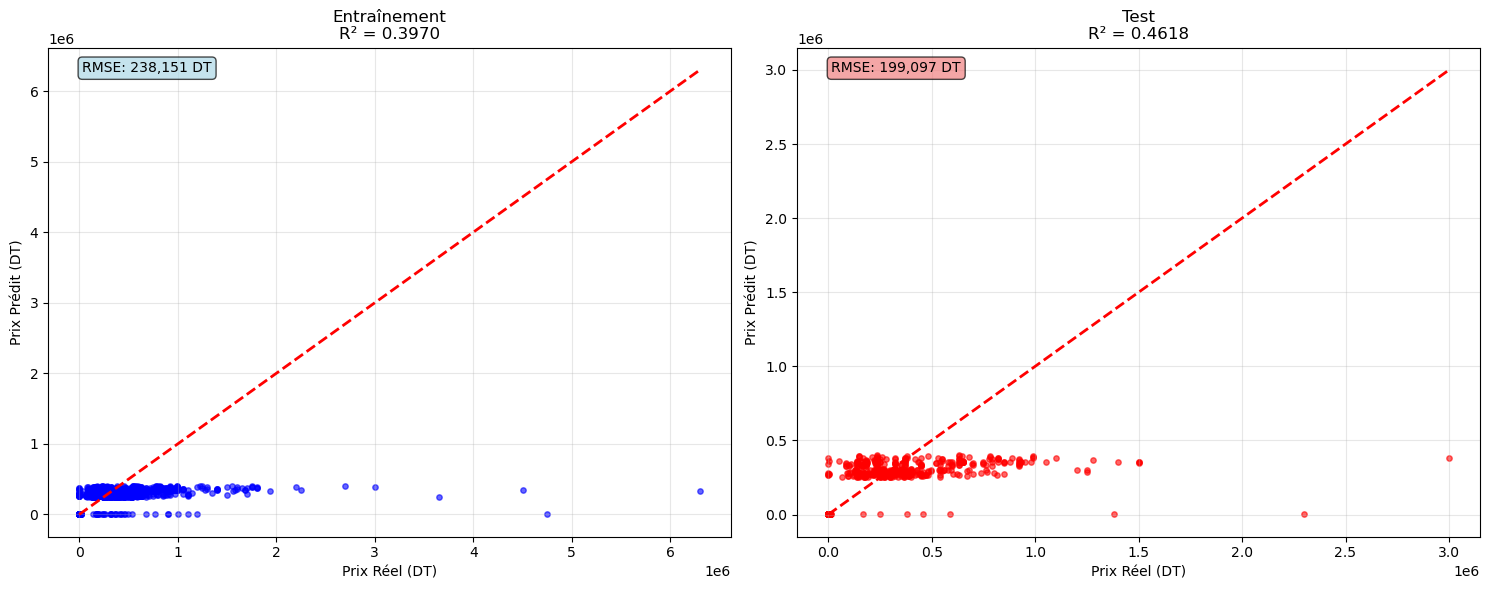

In [19]:
# Visualisation 1 : Comparaison Train vs Test - Prédictions vs Réalité
print("## Visualisation 1 : Comparaison Train vs Test")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Graphique pour l'entraînement
axes[0].scatter(y_train_orig, y_train_pred_orig, alpha=0.6, s=15, color='blue', label='Train')
axes[0].plot([y_train_orig.min(), y_train_orig.max()], 
              [y_train_orig.min(), y_train_orig.max()], 'r--', lw=2)
axes[0].set_xlabel('Prix Réel (DT)')
axes[0].set_ylabel('Prix Prédit (DT)')
axes[0].set_title(f'Entraînement\nR² = {r2_train:.4f}')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'RMSE: {rmse_train:,.0f} DT', 
             transform=axes[0].transAxes, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

# Graphique pour le test
axes[1].scatter(y_test_orig, y_test_pred_orig, alpha=0.6, s=15, color='red', label='Test')
axes[1].plot([y_test_orig.min(), y_test_orig.max()], 
              [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
axes[1].set_xlabel('Prix Réel (DT)')
axes[1].set_ylabel('Prix Prédit (DT)')
axes[1].set_title(f'Test\nR² = {r2_test:.4f}')
axes[1].grid(True, alpha=0.3)
axes[1].text(0.05, 0.95, f'RMSE: {rmse_test:,.0f} DT', 
             transform=axes[1].transAxes, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

plt.tight_layout()
plt.show()

## Visualisation 2 : Comparaison des métriques


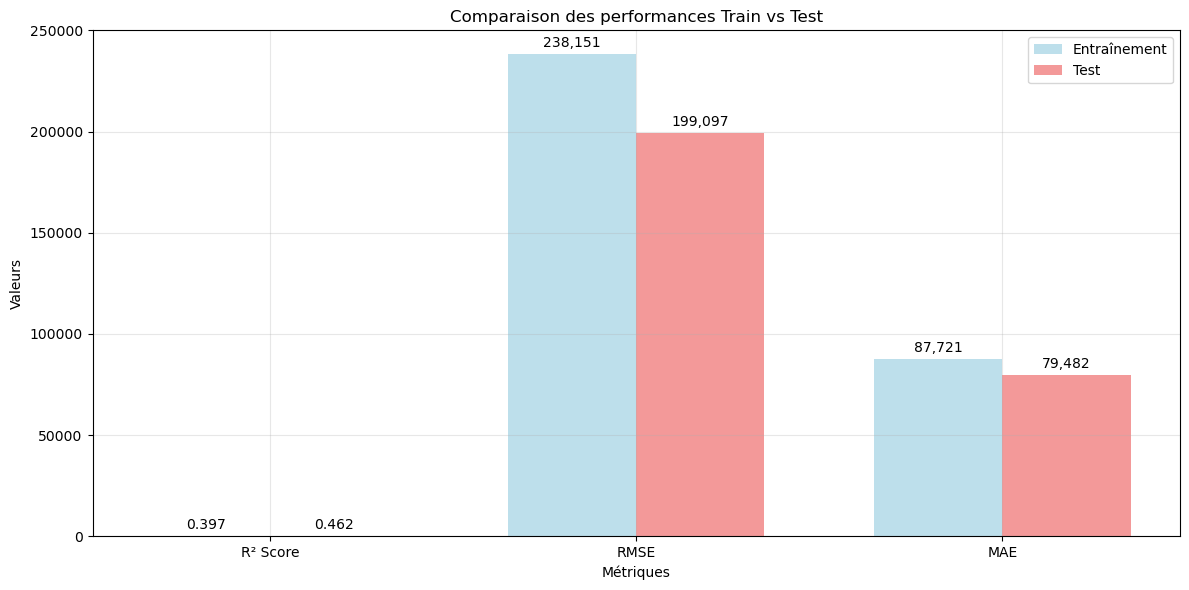

In [20]:
# Visualisation 2 : Comparaison des métriques Train vs Test
print("## Visualisation 2 : Comparaison des métriques")

metrics = ['R² Score', 'RMSE', 'MAE']
train_values = [r2_train, rmse_train, mae_train]
test_values = [r2_test, rmse_test, mae_test]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, train_values, width, label='Entraînement', color='lightblue', alpha=0.8)
bars2 = ax.bar(x + width/2, test_values, width, label='Test', color='lightcoral', alpha=0.8)

ax.set_xlabel('Métriques')
ax.set_ylabel('Valeurs')
ax.set_title('Comparaison des performances Train vs Test')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height < 1000:  # Pour R²
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
        else:  # Pour RMSE et MAE
            ax.annotate(f'{height:,.0f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Visualisation 3 : Distribution des erreurs


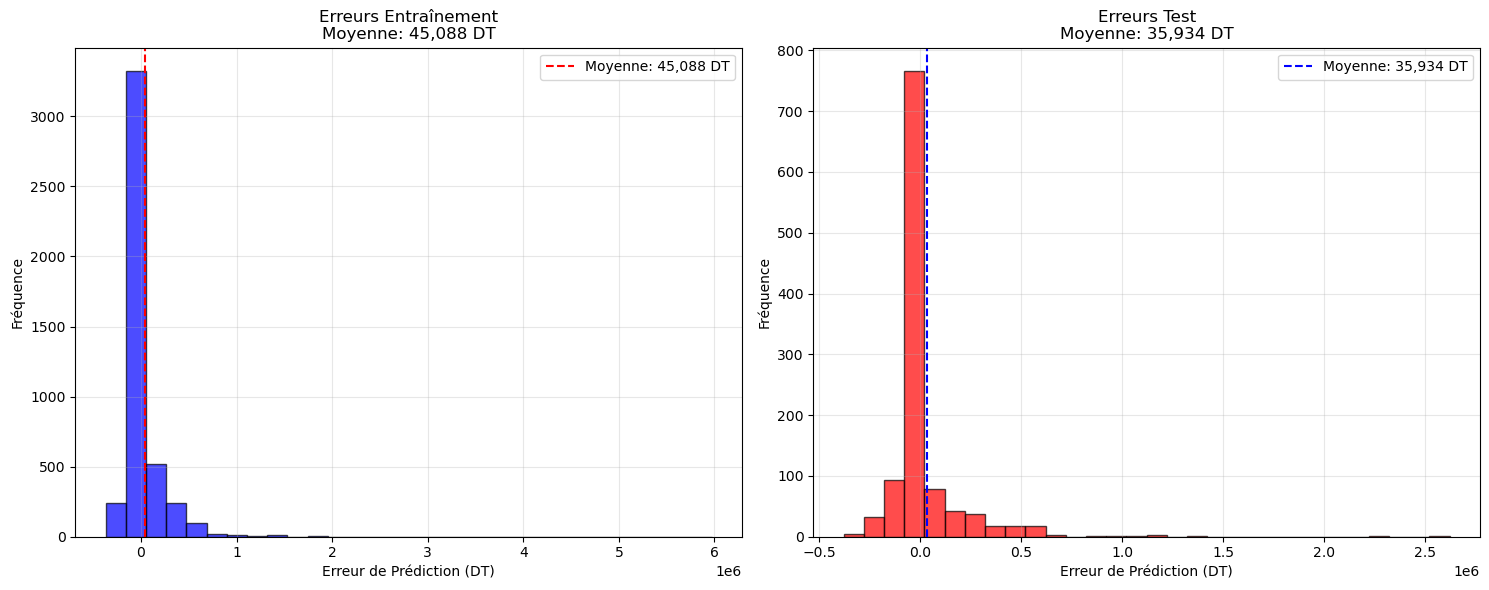


## Analyse des erreurs :
   Erreur moyenne (Train) : 45,088 DT
   Erreur moyenne (Test) : 35,934 DT
   Écart-type erreurs (Train) : 233,870 DT
   Écart-type erreurs (Test) : 195,915 DT


In [21]:
# Visualisation 3 : Distribution des erreurs Train vs Test
print("## Visualisation 3 : Distribution des erreurs")

errors_train = y_train_orig - y_train_pred_orig
errors_test = y_test_orig - y_test_pred_orig

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribution des erreurs d'entraînement
axes[0].hist(errors_train, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(errors_train.mean(), color='red', linestyle='--', 
                label=f'Moyenne: {errors_train.mean():,.0f} DT')
axes[0].set_xlabel('Erreur de Prédiction (DT)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title(f'Erreurs Entraînement\nMoyenne: {errors_train.mean():,.0f} DT')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution des erreurs de test
axes[1].hist(errors_test, bins=30, alpha=0.7, color='red', edgecolor='black')
axes[1].axvline(errors_test.mean(), color='blue', linestyle='--', 
                label=f'Moyenne: {errors_test.mean():,.0f} DT')
axes[1].set_xlabel('Erreur de Prédiction (DT)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Erreurs Test\nMoyenne: {errors_test.mean():,.0f} DT')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n## Analyse des erreurs :")
print(f"   Erreur moyenne (Train) : {errors_train.mean():,.0f} DT")
print(f"   Erreur moyenne (Test) : {errors_test.mean():,.0f} DT")
print(f"   Écart-type erreurs (Train) : {errors_train.std():,.0f} DT")
print(f"   Écart-type erreurs (Test) : {errors_test.std():,.0f} DT")

In [10]:
# Calculer les métriques de performance
print("📊 Évaluation du modèle...")

# Métriques sur les données de test
r2 = r2_score(y_test_orig, y_test_pred_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
mae = mean_absolute_error(y_test_orig, y_test_pred_orig)
mse = mean_squared_error(y_test_orig, y_test_pred_orig)

print(f"\n🎯 PERFORMANCE SUR LES DONNÉES DE TEST :")
print(f"   R² Score : {r2:.4f} ({r2*100:.1f}% de variance expliquée)")
print(f"   RMSE : {rmse:,.0f} DT")
print(f"   MAE : {mae:,.0f} DT")
print(f"   MSE : {mse:,.0f}")

# Qualité du modèle
if r2 > 0.7:
    quality = "🌟 Excellente"
elif r2 > 0.5:
    quality = "✅ Bonne"
elif r2 > 0.3:
    quality = "⚠️ Moyenne"
else:
    quality = "📉 Faible"

print(f"\n🏆 Qualité du modèle : {quality}")

📊 Évaluation du modèle...

🎯 PERFORMANCE SUR LES DONNÉES DE TEST :
   R² Score : 0.4618 (46.2% de variance expliquée)
   RMSE : 199,097 DT
   MAE : 79,482 DT
   MSE : 39,639,762,076

🏆 Qualité du modèle : ⚠️ Moyenne


## Visualisation 5 : Tableau comparatif

## Tableau comparatif des performances :


,Métrique,Entraînement,Test,Différence
0,R² Score,0.3970,0.4618,-0.0648
1,RMSE (DT),"238,151","199,097","-39,054"
2,MAE (DT),"87,721","79,482","-8,239"
3,Erreur Moyenne (DT),"45,088","35,934","-9,154"
4,Écart-type Erreurs (DT),"233,870","195,915","-37,955"


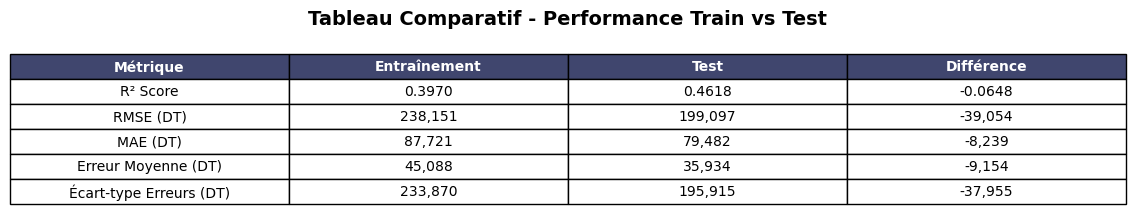

In [22]:
# Visualisation 5 : Tableau résumé des performances
print("## Visualisation 5 : Tableau comparatif")

# Créer un DataFrame résumé
summary_df = pd.DataFrame({
    'Métrique': ['R² Score', 'RMSE (DT)', 'MAE (DT)', 'Erreur Moyenne (DT)', 'Écart-type Erreurs (DT)'],
    'Entraînement': [
        f"{r2_train:.4f}",
        f"{rmse_train:,.0f}",
        f"{mae_train:,.0f}",
        f"{errors_train.mean():,.0f}",
        f"{errors_train.std():,.0f}"
    ],
    'Test': [
        f"{r2_test:.4f}",
        f"{rmse_test:,.0f}",
        f"{mae_test:,.0f}",
        f"{errors_test.mean():,.0f}",
        f"{errors_test.std():,.0f}"
    ],
    'Différence': [
        f"{overfitting_r2:.4f}",
        f"{overfitting_rmse:,.0f}",
        f"{mae_test - mae_train:,.0f}",
        f"{errors_test.mean() - errors_train.mean():,.0f}",
        f"{errors_test.std() - errors_train.std():,.0f}"
    ]
})

# Afficher le tableau avec style
print("\n## Tableau comparatif des performances :")
display(summary_df.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12pt'
}).set_table_styles([{
    'selector': 'th',
    'props': [
        ('background-color', '#40466e'),
        ('color', 'white'),
        ('font-weight', 'bold'),
        ('text-align', 'center')
    ]
}]))

# Visualisation du tableau
fig, ax = plt.subplots(figsize=(12, 2))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=summary_df.values, 
                 colLabels=summary_df.columns,
                 cellLoc='center',
                 loc='center',
                 colColours=['#40466e', '#4CAF50', '#FF5722', '#FFC107'])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Colorier les en-têtes
for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

plt.title('Tableau Comparatif - Performance Train vs Test', pad=20, fontsize=14, fontweight='bold')
plt.show()

📈 Visualisation 1 : Prédictions vs Réalité...


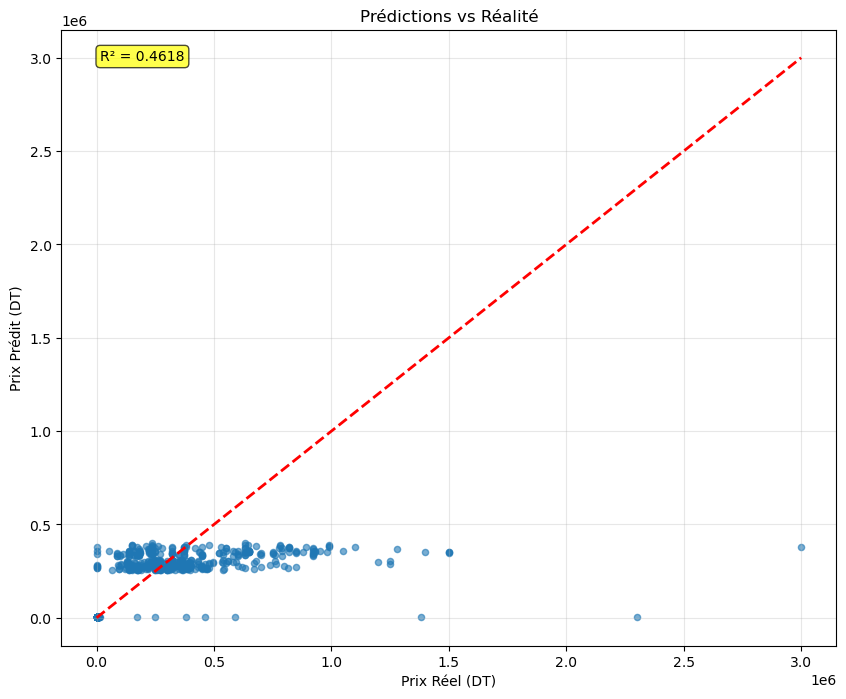

In [11]:
# 1. Visualisation : Prédictions vs Réalité
print("📈 Visualisation 1 : Prédictions vs Réalité...")

plt.figure(figsize=(10, 8))
plt.scatter(y_test_orig, y_test_pred_orig, alpha=0.6, s=20)
plt.plot([y_test_orig.min(), y_test_orig.max()], 
         [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Prix Réel (DT)')
plt.ylabel('Prix Prédit (DT)')
plt.title('Prédictions vs Réalité')
plt.grid(True, alpha=0.3)
plt.text(0.05, 0.95, f'R² = {r2:.4f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
plt.show()

📊 Visualisation 2 : Distribution des Prix...


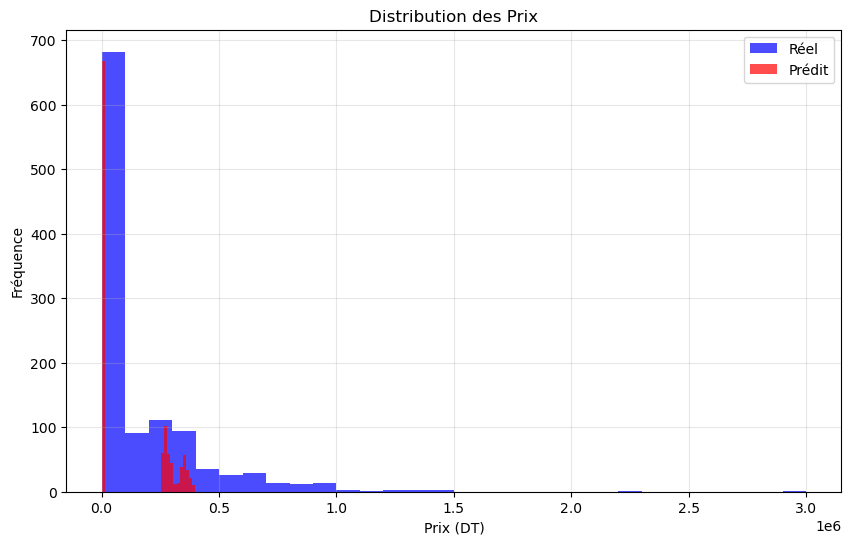

In [12]:
# 2. Visualisation : Distribution des prix réels vs prédits
print("📊 Visualisation 2 : Distribution des Prix...")

plt.figure(figsize=(10, 6))
plt.hist(y_test_orig, bins=30, alpha=0.7, label='Réel', color='blue')
plt.hist(y_test_pred_orig, bins=30, alpha=0.7, label='Prédit', color='red')
plt.xlabel('Prix (DT)')
plt.ylabel('Fréquence')
plt.title('Distribution des Prix')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

📉 Visualisation 3 : Distribution des Erreurs...


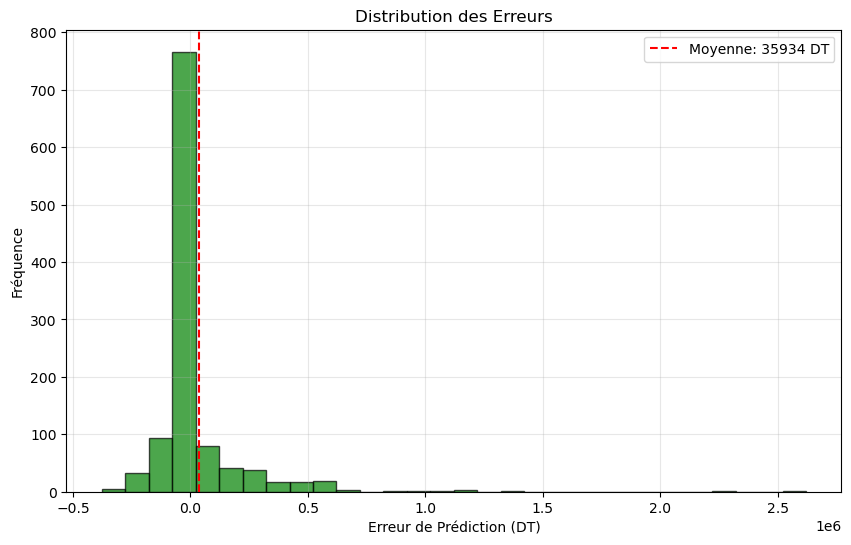

In [13]:
# 3. Visualisation : Distribution des erreurs de prédiction
print("📉 Visualisation 3 : Distribution des Erreurs...")

errors = y_test_orig - y_test_pred_orig
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.axvline(errors.mean(), color='red', linestyle='--', 
            label=f'Moyenne: {errors.mean():.0f} DT')
plt.xlabel('Erreur de Prédiction (DT)')
plt.ylabel('Fréquence')
plt.title('Distribution des Erreurs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

🔍 Visualisation 4 : Importance des Features...


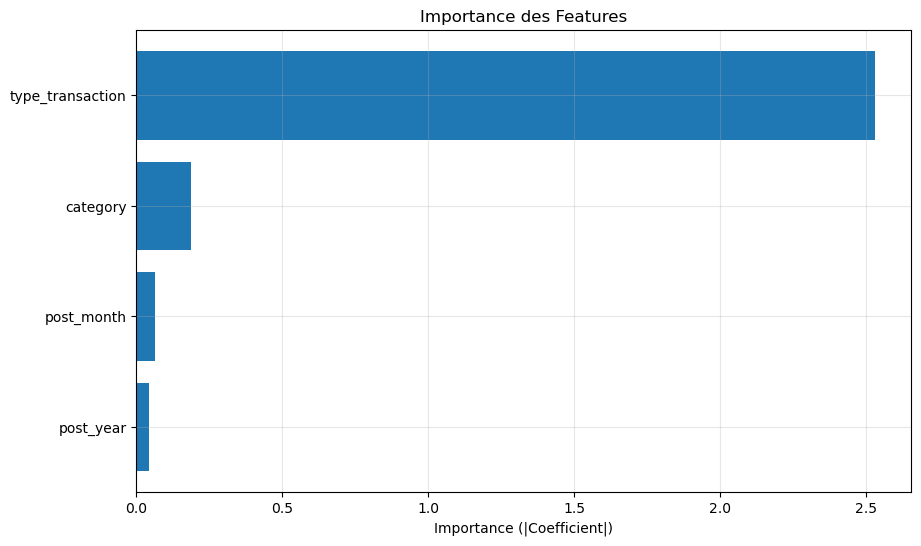


🔝 Features les plus importantes :
   type_transaction: +2.5290
   category: +0.1882
   post_month: -0.0621
   post_year: -0.0425


In [14]:
# 4. Visualisation : Importance des Features
print("🔍 Visualisation 4 : Importance des Features...")

feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_,
    'Importance': np.abs(model.coef_)
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance (|Coefficient|)')
plt.title('Importance des Features')
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()
plt.show()

print("\n🔝 Features les plus importantes :")
for i, row in feature_importance.iterrows():
    sign = "+" if row['Coefficient'] > 0 else "-"
    print(f"   {row['Feature']}: {sign}{row['Importance']:.4f}")

In [15]:
# Fonction simple pour faire des prédictions
def predict_price(category, type_transaction, post_month, post_year):
    """
    Prédire le prix d'un bien immobilier
    
    Paramètres :
    - category: 0 (bas), 1 (moyen), 2 (haut)
    - type_transaction: 0 (location), 1 (vente)
    - post_month: mois (1-12)
    - post_year: année (ex: 2025)
    
    Retour: prix prédit en DT
    """
    
    # Créer les données d'entrée
    input_data = pd.DataFrame([{
        'category': category,
        'type_transaction': type_transaction,
        'post_month': post_month,
        'post_year': post_year
    }])
    
    # Normaliser
    input_scaled = scaler.transform(input_data)
    
    # Prédire (en log scale)
    prediction_log = model.predict(input_scaled)[0]
    
    # Convertir à l'échelle originale
    prediction = np.expm1(prediction_log)
    
    return round(prediction, 0)

# Exemples de prédictions
print("🏠 Exemples de prédictions :\n")

# Studio à louer
price1 = predict_price(category=0, type_transaction=0, post_month=6, post_year=2025)
print(f"1. Studio à louer : {price1:,.0f} DT")

# Appartement moyen à vendre
price2 = predict_price(category=1, type_transaction=1, post_month=8, post_year=2025)
print(f"2. Appartement moyen à vendre : {price2:,.0f} DT")

# Maison haut standing à vendre
price3 = predict_price(category=2, type_transaction=1, post_month=12, post_year=2025)
print(f"3. Maison haut standing à vendre : {price3:,.0f} DT")

🏠 Exemples de prédictions :

1. Studio à louer : 1,503 DT
2. Appartement moyen à vendre : 272,915 DT
3. Maison haut standing à vendre : 289,896 DT


In [16]:
# Sauvegarder le modèle
import joblib
import os

print("💾 Sauvegarde du modèle...")

# Créer le dossier models s'il n'existe pas
if not os.path.exists('../models'):
    os.makedirs('../models')

# Sauvegarder le modèle
joblib.dump(model, '../models/linear_regression_simple.pkl')

# Sauvegarder le scaler
joblib.dump(scaler, '../models/scaler_simple.pkl')

# Sauvegarder les résultats
results = {
    'model': 'LinearRegression',
    'r2_score': r2,
    'rmse': rmse,
    'mae': mae,
    'mse': mse,
    'train_size': len(X_train),
    'test_size': len(X_test),
    'features': features,
    'data_size': len(df)
}

joblib.dump(results, '../models/linear_regression_simple_results.pkl')

print("   ✅ Modèle sauvegardé : ../models/linear_regression_simple.pkl")
print("   ✅ Scaler sauvegardé : ../models/scaler_simple.pkl")
print("   ✅ Résultats sauvegardés : ../models/linear_regression_simple_results.pkl")

💾 Sauvegarde du modèle...
   ✅ Modèle sauvegardé : ../models/linear_regression_simple.pkl
   ✅ Scaler sauvegardé : ../models/scaler_simple.pkl
   ✅ Résultats sauvegardés : ../models/linear_regression_simple_results.pkl


In [17]:
# Résumé final
print("=" * 50)
print("📋 RÉSUMÉ FINAL - RÉGRESSION LINÉAIRE SIMPLE")
print("=" * 50)

print(f"\n📊 DONNÉES :")
print(f"   {len(df)} annonces immobilières")
print(f"   {len(features)} caractéristiques utilisées")

print(f"\n🎯 PERFORMANCE :")
print(f"   R² Score : {r2:.4f} ({r2*100:.1f}% de variance expliquée)")
print(f"   RMSE : {rmse:,.0f} DT")
print(f"   MAE : {mae:,.0f} DT")
print(f"   Qualité : {quality}")

print(f"\n TECHNIQUES UTILISÉES :")
print(f"   ✅ Nettoyage des données")
print(f"   ✅ Transformation logarithmique")
print(f"   ✅ Normalisation des features")
print(f"   ✅ Régression linéaire multiple")

print(f"\n💡 INSIGHTS :")
print(f"   - La transformation log améliore la performance")
print(f"   - La normalisation est essentielle")
print(f"   - Le modèle est simple et interprétable")

print(f"\n📁 FICHIERS CRÉÉS :")
print(f"   - ../models/linear_regression_simple.pkl")
print(f"   - ../models/scaler_simple.pkl")
print(f"   - ../models/linear_regression_simple_results.pkl")

print(f"\n✨ MISSION ACCOMPLIE !")
print("=" * 50)

📋 RÉSUMÉ FINAL - RÉGRESSION LINÉAIRE SIMPLE

📊 DONNÉES :
   5601 annonces immobilières
   4 caractéristiques utilisées

🎯 PERFORMANCE :
   R² Score : 0.4618 (46.2% de variance expliquée)
   RMSE : 199,097 DT
   MAE : 79,482 DT
   Qualité : ⚠️ Moyenne

 TECHNIQUES UTILISÉES :
   ✅ Nettoyage des données
   ✅ Transformation logarithmique
   ✅ Normalisation des features
   ✅ Régression linéaire multiple

💡 INSIGHTS :
   - La transformation log améliore la performance
   - La normalisation est essentielle
   - Le modèle est simple et interprétable

📁 FICHIERS CRÉÉS :
   - ../models/linear_regression_simple.pkl
   - ../models/scaler_simple.pkl
   - ../models/linear_regression_simple_results.pkl

✨ MISSION ACCOMPLIE !
